# 1. Random Forest Regressor — Member 3
**IT3091 · House Price Prediction and Valuation Feature Analysis**  
**Ahamed M.A.W · IT24103352 · Group 2026-AI-08K**

This notebook implements Member 3's Random Forest contribution under the [explicit team allocation](../../docs/model_training_phases.md). It produces an executed experiment, comparison metrics and a complete fitted pipeline.

## 2. Objective
Evaluate a bagging ensemble for Ames house-price prediction using the completed Member 3 preprocessing module. Tune only the six assigned configurations and explain prediction errors and valuation-feature importance.

The preprocessing implementation, raw records, processed handover CSVs and earlier notebooks remain unchanged. The existing preprocessing notebook is not executed. This notebook neither selects a group-wide winning model nor implements another member's work.

## 3. Common team comparison contract
**5-Fold Development Cross-Validation** uses all 1,460 labelled rows in original order and KFold(n_splits=5, shuffle=True, random_state=42).

| Decision | Definition |
|---|---|
| Fitting target | log1p(SalePrice) |
| Prediction conversion | expm1(log prediction), before every reported metric |
| Primary RMSE, MAE and R² | Arithmetic mean of the five validation-fold dollar metrics |
| Train R² / Validation R² | Arithmetic mean of the corresponding five dollar R² values |
| Overfit gap | Mean Train R² minus mean Validation R² |
| Supplementary OOF metrics | Metrics on all aligned held-out predictions pooled together |
| Standard deviations | Population standard deviation across five folds (ddof=0); not a confidence interval |
| Parameter selection | Lowest mean validation RMSE in dollars |

The tuning and selected-model evaluation reuse the same folds. Scores are development estimates subject to selection optimism, not an independent test or nested-CV estimate. The team's example scores and example RF configuration are not used as results.

## 4. Imports, paths and reproducibility
Run from the repository root or any directory beneath it. All outputs use explicit repository-relative paths. Existing dependencies suffice. The package versions, raw-data hash, preprocessing hash and current Git commit are recorded for reproducibility.

In [1]:
from pathlib import Path
import sys
sys.dont_write_bytecode = True
import copy
import hashlib
import json
import platform
import subprocess
import time

import joblib
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Rectangle
from matplotlib.ticker import FuncFormatter
import numpy as np
import pandas as pd
import scipy
import seaborn as sns
import sklearn
from IPython.display import Markdown, display
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, ParameterGrid
from sklearn.pipeline import Pipeline

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'src/member_03/preprocessing.py').is_file()
             and (p / 'data/raw/house-prices-advanced-regression-techniques/train.csv').is_file()), None)
assert ROOT is not None, 'Run this notebook from inside the repository.'
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.member_03 import load_ames_data, build_preprocessor, get_feature_names

RANDOM_STATE = 42
MODEL_PATH = ROOT / 'notebooks/Member_03/random_forest_model.joblib'
METRICS_PATH = ROOT / 'reports/model_results/member3_rf_metrics.json'
RAW_TRAIN_PATH = ROOT / 'data/raw/house-prices-advanced-regression-techniques/train.csv'
PREPROCESSING_PATH = ROOT / 'src/member_03/preprocessing.py'
sha256 = lambda p: hashlib.sha256(p.read_bytes()).hexdigest()
creation_flags = subprocess.CREATE_NO_WINDOW if sys.platform == 'win32' else 0
training_base_commit = subprocess.check_output(
    ['git', 'rev-parse', 'HEAD'], cwd=ROOT, text=True,
    creationflags=creation_flags).strip()
provenance = {
    'git_commit_used_as_training_base': training_base_commit,
    'raw_train_sha256': sha256(RAW_TRAIN_PATH),
    'preprocessing_sha256': sha256(PREPROCESSING_PATH),
}
package_versions = {
    'Python': platform.python_version(), 'numpy': np.__version__,
    'pandas': pd.__version__, 'scikit-learn': sklearn.__version__,
    'scipy': scipy.__version__, 'matplotlib': matplotlib.__version__,
    'seaborn': sns.__version__, 'joblib': joblib.__version__,
}
sns.set_theme(style='whitegrid', context='notebook', palette='colorblind')
plt.rcParams.update({'figure.dpi': 120, 'axes.titleweight': 'bold',
                     'axes.spines.top': False, 'axes.spines.right': False})
BLUE, ORANGE, TEAL = '#275D8C', '#C86B32', '#247D79'
dollar_axis = FuncFormatter(lambda value, pos: f'USD {value / 1000:,.0f}k')
display(pd.Series(package_versions, name='Executed environment').to_frame())
display(pd.Series(provenance, name='Training provenance').to_frame())

,Executed environment
Python,3.14.3
numpy,2.4.2
pandas,2.3.3
scikit-learn,1.8.0
scipy,1.17.1
matplotlib,3.10.8
seaborn,0.13.2
joblib,1.5.3


,Training provenance
git_commit_used_as_training_base,a92181d734cb14c26c24769d3be35b2ec68cb3fa
raw_train_sha256,ed142e0a97bd49fc3b46c930209c55750fc4e806f5430c...
preprocessing_sha256,57d34307ceadc503fdd33811f3a1733bae01c152b2f4a8...


## 5. Load and validate raw data
The shared loader preserves literal NA and None tokens for semantic cleaning. Kaggle test rows are unlabelled and do not participate in fitting, tuning or metric calculations. This is a schema check, not repeated exploratory analysis.

In [2]:
train_df, test_df = load_ames_data(ROOT)
assert train_df.shape == (1460, 81) and test_df.shape == (1459, 80)
assert train_df['Id'].is_unique and test_df['Id'].is_unique
assert set(train_df['Id']).isdisjoint(test_df['Id'])
assert 'SalePrice' not in test_df
assert np.isfinite(train_df['SalePrice']).all() and train_df['SalePrice'].gt(0).all()
assert train_df.drop(columns='SalePrice').columns.equals(test_df.columns)
original_ids = train_df['Id'].to_numpy(copy=True)
raw_snapshot = train_df.copy(deep=True)
display(pd.DataFrame({
    'File': ['train.csv', 'test.csv'], 'Rows': [len(train_df), len(test_df)],
    'Columns': [train_df.shape[1], test_df.shape[1]],
    'Use': ['All labelled rows: development CV and final fit', 'Schema check only; no labels'],
}))

,File,Rows,Columns,Use
0,train.csv,1460,81,All labelled rows: development CV and final fit
1,test.csv,1459,80,Schema check only; no labels


## 6. Prepare predictors and target
Keep IDs only for alignment. The preprocessor internally enforces its existing property allowlist, including the five transaction/availability exclusions. No rows are filtered, sorted or removed. Feature logarithms remain disabled; the log1p operation below applies only to the target.

In [3]:
X = train_df.drop(columns=['Id', 'SalePrice'])
y_dollars = train_df['SalePrice'].copy()
y_log = np.log1p(y_dollars)
assert X.shape == (1460, 79)
assert X.index.equals(y_dollars.index) and X.index.equals(y_log.index)
assert np.array_equal(original_ids, train_df['Id'].to_numpy())
np.testing.assert_allclose(np.expm1(y_log), y_dollars, rtol=1e-12)

cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_splits = list(cv.split(X, y_log))
coverage = np.zeros(len(X), dtype=int)
for train_idx, val_idx in cv_splits:
    assert len(train_idx) == 1168 and len(val_idx) == 292
    assert np.intersect1d(train_idx, val_idx).size == 0
    assert np.array_equal(np.sort(np.concatenate([train_idx, val_idx])), np.arange(len(X)))
    coverage[val_idx] += 1
assert np.all(coverage == 1)
# Record fold memberships by Id so the comparison lead can verify exact alignment.
fold_validation_ids = [original_ids[val_idx].astype(int).tolist() for _, val_idx in cv_splits]
print('Five fixed splits verified: 1,168 training + 292 validation rows per fold.')
print('All 1,460 rows appear in validation exactly once; original order preserved.')

Five fixed splits verified: 1,168 training + 292 validation rows per fold.
All 1,460 rows appear in validation exactly once; original order preserved.


## 7. Leakage-safe Random Forest pipeline
Each cloned pipeline fits semantic preprocessing, applicable medians and one-hot vocabulary using only its current training fold. Validation rows use that fitted state without updating it. Full-training processed CSVs are never read.

Dense output simplifies inspection at this dataset size. No scaling or numerical-feature logarithms are introduced. Bootstrap sampling and fixed random_state provide the forest's ensemble randomness; max_features=1.0 considers all transformed features at each split.

Fresh unfitted pipeline: prep → reg


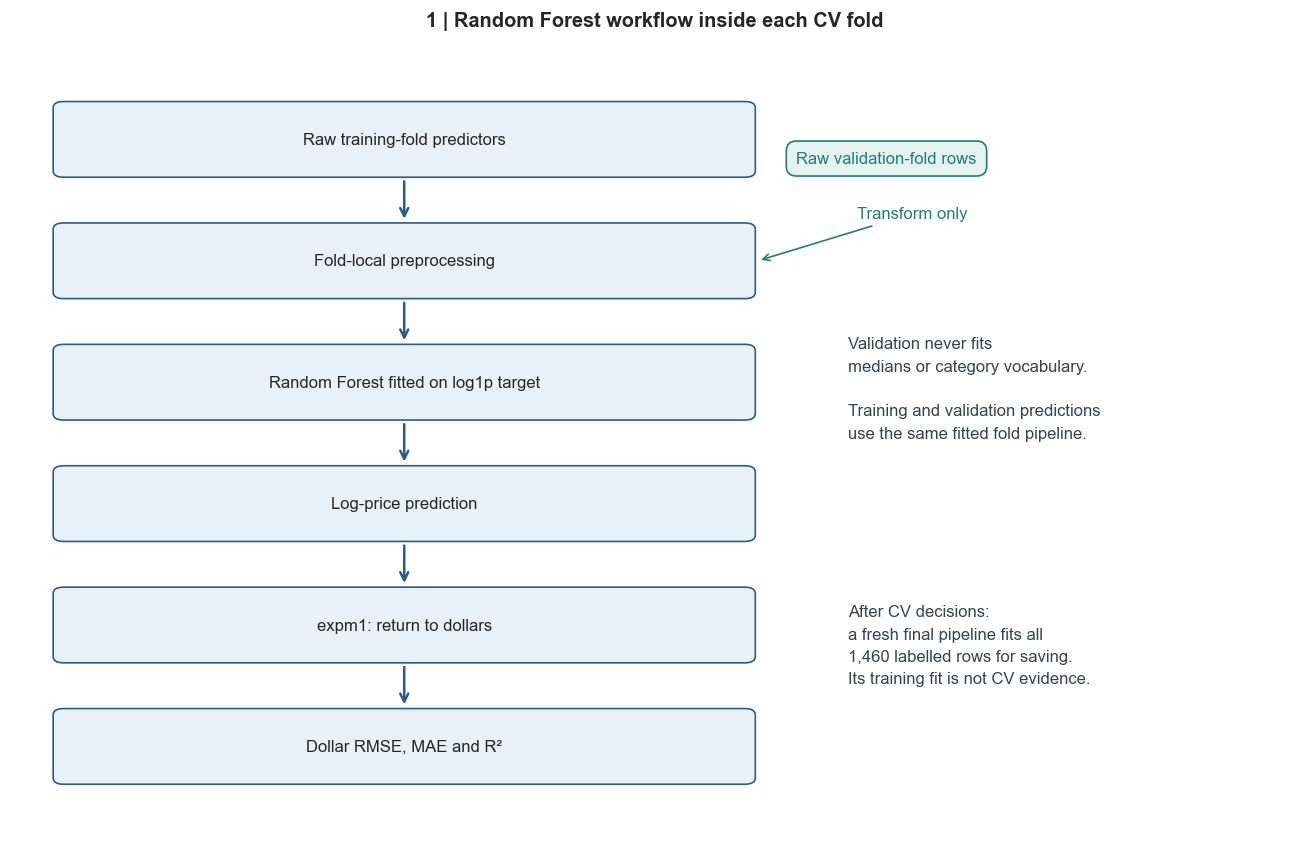

In [4]:
FIXED_PARAMS = {
    'random_state': 42, 'n_jobs': -1, 'criterion': 'squared_error',
    'bootstrap': True, 'max_features': 1.0, 'min_samples_split': 2,
    'min_samples_leaf': 1, 'oob_score': False,
}
base_pipeline = Pipeline([
    ('prep', build_preprocessor(configuration='unscaled', log_numeric=False, sparse_output=False)),
    ('reg', RandomForestRegressor(**FIXED_PARAMS)),
])
assert not hasattr(base_pipeline.named_steps['prep'].named_steps['impute'], 'statistics_')
assert not hasattr(base_pipeline.named_steps['reg'], 'estimators_')
print('Fresh unfitted pipeline:', ' → '.join(base_pipeline.named_steps))

fig, ax = plt.subplots(figsize=(10.8, 7.0), layout='constrained')
ax.set(xlim=(0, 1), ylim=(0, 1))
ax.axis('off')
ax.set_title('1 | Random Forest workflow inside each CV fold', pad=16)
labels = ['Raw training-fold predictors', 'Fold-local preprocessing', 'Random Forest fitted on log1p target',
          'Log-price prediction', 'expm1: return to dollars', 'Dollar RMSE, MAE and R²']
ys = np.linspace(.89, .12, len(labels))
for i, (label, y_pos) in enumerate(zip(labels, ys)):
    ax.add_patch(FancyBboxPatch((.04, y_pos - .04), .53, .08,
                 boxstyle='round,pad=0.008', facecolor='#E9F1F8', edgecolor=BLUE))
    ax.text(.305, y_pos, label, ha='center', va='center', fontsize=10)
    if i:
        ax.annotate('', xy=(.305, y_pos + .049), xytext=(.305, ys[i - 1] - .049),
                    arrowprops={'arrowstyle': '->', 'color': BLUE, 'lw': 1.5})
ax.text(.68, .86, 'Raw validation-fold rows', ha='center', fontsize=10, color=TEAL,
        bbox={'boxstyle': 'round,pad=.6', 'facecolor': '#E5F3F0', 'edgecolor': TEAL})
ax.annotate('Transform only', xy=(.58, ys[1]), xytext=(.70, .79), fontsize=10,
            ha='center', color=TEAL, arrowprops={'arrowstyle': '->', 'color': TEAL})
ax.text(.65, .64, 'Validation never fits\nmedians or category vocabulary.\n\nTraining and validation predictions\nuse the same fitted fold pipeline.',
        va='top', fontsize=10, linespacing=1.6, color='#334455')
ax.text(.65, .30, 'After CV decisions:\na fresh final pipeline fits all\n1,460 labelled rows for saving.\nIts training fit is not CV evidence.',
        va='top', fontsize=10, linespacing=1.6, color='#334455')
plt.show()
plt.close(fig)

**Figure 1 interpretation.** The fitting boundary is the current training fold. Validation rows enter only through transform/predict, and all reported scores follow the inverse target transformation. This is a conceptual workflow; the final saved artifact is fitted separately after development evaluation.

## 8. Hyperparameter search
The assigned grid contains exactly six candidates: n_estimators ∈ {100, 200} and max_depth ∈ {10, 16, 20}. GridSearchCV evaluates each complete pipeline on the materialized shared folds.

All three custom scorers convert both log targets and log predictions back to dollars. RMSE and MAE scorers are negated for scikit-learn's higher-is-better convention; the table reverses that sign. Search runs sequentially while each forest uses available cores. No automatic full-data refit occurs during search.

In [5]:
def rmse_from_log(y_true_log, y_pred_log):
    return float(np.sqrt(mean_squared_error(np.expm1(y_true_log), np.expm1(y_pred_log))))


def mae_from_log(y_true_log, y_pred_log):
    return float(mean_absolute_error(np.expm1(y_true_log), np.expm1(y_pred_log)))


def r2_from_log(y_true_log, y_pred_log):
    return float(r2_score(np.expm1(y_true_log), np.expm1(y_pred_log)))


scoring = {
    'rmse_dollars': make_scorer(rmse_from_log, greater_is_better=False),
    'mae_dollars': make_scorer(mae_from_log, greater_is_better=False),
    'r2_dollars': make_scorer(r2_from_log),
}
# A small fixed example checks conversion and distinguishes dollar R² from log R².
probe_true = np.array([100_000., 200_000., 500_000.])
probe_pred = np.array([110_000., 180_000., 400_000.])
assert np.isclose(r2_from_log(np.log1p(probe_true), np.log1p(probe_pred)),
                  r2_score(probe_true, probe_pred))
assert not np.isclose(r2_score(probe_true, probe_pred),
                      r2_score(np.log1p(probe_true), np.log1p(probe_pred)))
assert np.isclose(rmse_from_log(np.log1p(probe_true), np.log1p(probe_pred)),
                  np.sqrt(mean_squared_error(probe_true, probe_pred)))
assert np.isclose(mae_from_log(np.log1p(probe_true), np.log1p(probe_pred)),
                  mean_absolute_error(probe_true, probe_pred))

param_grid = {'reg__n_estimators': [100, 200], 'reg__max_depth': [10, 16, 20]}
assert len(list(ParameterGrid(param_grid))) == 6
search = GridSearchCV(
    base_pipeline, param_grid=param_grid, scoring=scoring, cv=cv_splits,
    refit=False, return_train_score=True, n_jobs=1, error_score='raise', verbose=1,
)
search_started = time.perf_counter()
search.fit(X, y_log)
search_seconds = time.perf_counter() - search_started
results = search.cv_results_
tuning_table = pd.DataFrame({
    'n_estimators': [p['reg__n_estimators'] for p in results['params']],
    'max_depth': [p['reg__max_depth'] for p in results['params']],
    'Validation RMSE ($)': -results['mean_test_rmse_dollars'],
    'RMSE std ($)': results['std_test_rmse_dollars'],
    'Validation MAE ($)': -results['mean_test_mae_dollars'],
    'Validation R²': results['mean_test_r2_dollars'],
    'Train R²': results['mean_train_r2_dollars'],
    'RMSE rank': results['rank_test_rmse_dollars'],
})
tuning_table['Overfit gap'] = tuning_table['Train R²'] - tuning_table['Validation R²']
assert len(tuning_table) == 6 and np.isfinite(tuning_table.to_numpy()).all()
display(tuning_table.style.format({
    'Validation RMSE ($)': '{:,.2f}', 'RMSE std ($)': '{:,.2f}',
    'Validation MAE ($)': '{:,.2f}', 'Validation R²': '{:.5f}',
    'Train R²': '{:.5f}', 'Overfit gap': '{:.5f}',
}).hide(axis='index'))
print(f'Completed 30 fold fits in {search_seconds:.1f} seconds; no full-data refit.')

Fitting 5 folds for each of 6 candidates, totalling 30 fits


n_estimators,max_depth,Validation RMSE ($),RMSE std ($),Validation MAE ($),Validation R²,Train R²,RMSE rank,Overfit gap
100,10,"31,263.21","7,165.38","17,646.44",0.83160,0.97656,6,0.14496
200,10,"31,208.57","7,289.04","17,646.72",0.83176,0.97673,5,0.14497
100,16,"30,866.58","7,075.79","17,501.39",0.83585,0.97949,3,0.14364
200,16,"30,859.46","6,985.00","17,490.80",0.83625,0.97989,2,0.14364
100,20,"30,987.97","7,047.60","17,490.65",0.83450,0.97951,4,0.14501
200,20,"30,814.76","6,965.32","17,506.27",0.83664,0.98013,1,0.14348


Completed 30 fold fits in 18.6 seconds; no full-data refit.


## 9. Best Random Forest configuration
Selection uses the smallest mean validation dollar RMSE in the actual search results. Exact ties retain the first candidate in the fixed grid order (shallower depth, then fewer trees). Standard deviations show fold variability; the lowest mean does not establish statistically significant superiority.

,Selected by development CV
max_depth,20
n_estimators,200


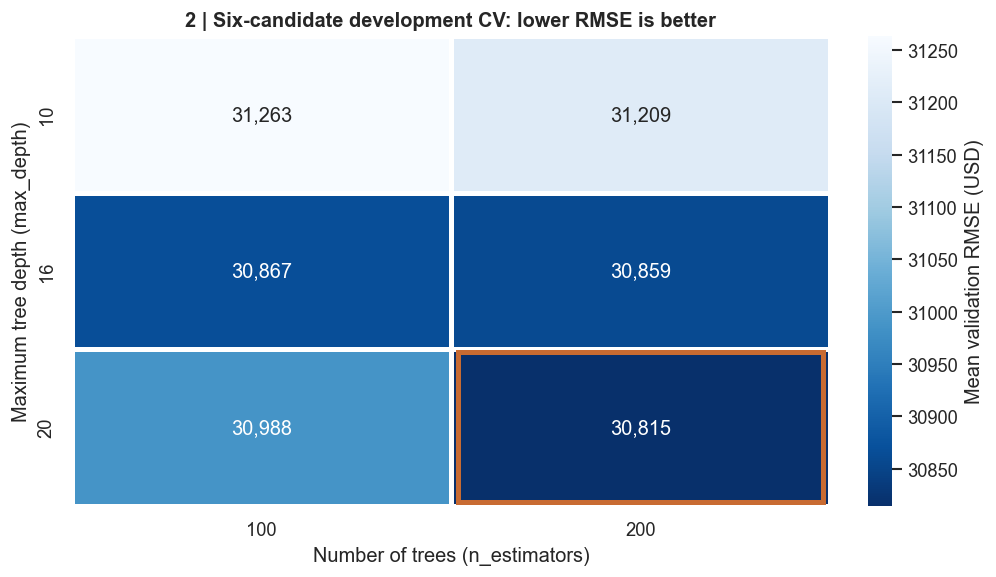

**Figure 2 interpretation.** The orange border marks **200 trees, maximum depth 20**, selected at mean validation RMSE **USD 30,814.76**. All six cells use identical folds and dollar scoring. This is tuning evidence, not independent testing.

In [6]:
best_index = int(np.argmin(tuning_table['Validation RMSE ($)'].to_numpy()))
best_pipeline_params = dict(results['params'][best_index])
best_params = {key.removeprefix('reg__'): int(value) for key, value in best_pipeline_params.items()}
assert int(results['rank_test_rmse_dollars'][best_index]) == 1
selected_template = clone(base_pipeline).set_params(**best_pipeline_params)
display(pd.Series(best_params, name='Selected by development CV').to_frame())

heatmap_data = tuning_table.pivot(index='max_depth', columns='n_estimators', values='Validation RMSE ($)')
fig, ax = plt.subplots(figsize=(8.2, 4.7), layout='constrained')
sns.heatmap(heatmap_data, annot=True, fmt=',.0f', cmap='Blues_r', linewidths=2,
            cbar_kws={'label': 'Mean validation RMSE (USD)'}, ax=ax)
col = list(heatmap_data.columns).index(best_params['n_estimators'])
row = list(heatmap_data.index).index(best_params['max_depth'])
ax.add_patch(Rectangle((col + .02, row + .02), .96, .96, fill=False, edgecolor=ORANGE, lw=3))
ax.set(title='2 | Six-candidate development CV: lower RMSE is better',
       xlabel='Number of trees (n_estimators)', ylabel='Maximum tree depth (max_depth)')
plt.show()
plt.close(fig)
display(Markdown(
    f'**Figure 2 interpretation.** The orange border marks **{best_params["n_estimators"]} trees, '
    f'maximum depth {best_params["max_depth"]}**, selected at mean validation RMSE '
    f'**USD {tuning_table.loc[best_index, "Validation RMSE ($)"]:,.2f}**. '
    'All six cells use identical folds and dollar scoring. This is tuning evidence, not independent testing.'
))

## 10. Five-fold evaluation
Fit a fresh clone of the selected complete pipeline in each of the same five folds. Keep train and validation predictions in memory with their row positions; fill each OOF position exactly once. The fitted imputer row count, training median and encoder vocabulary are checked against that fold's training data. Transform/predict must not mutate learned preprocessing state.

This second pass supplies aligned diagnostics and detailed fold evidence. Reusing the tuning folds does not remove hyperparameter-selection optimism.

In [7]:
fold_records = []
fold_predictions = []
oof_predictions = np.full(len(X), np.nan)
oof_fold = np.zeros(len(X), dtype=int)
oof_coverage = np.zeros(len(X), dtype=int)
for fold, (train_idx, val_idx) in enumerate(cv_splits, start=1):
    fold_pipeline = clone(selected_template)
    fold_prep = fold_pipeline.named_steps['prep']
    assert not hasattr(fold_prep.named_steps['impute'], 'statistics_')
    fold_pipeline.fit(X.iloc[train_idx], y_log.iloc[train_idx])
    imputer = fold_prep.named_steps['impute']
    assert imputer.fit_row_count_ == len(train_idx)
    training_clean = fold_prep.named_steps['semantic'].transform(X.iloc[train_idx])
    assert np.isclose(imputer.statistics_['LotFrontage'], training_clean['LotFrontage'].median())
    encoder = fold_prep.named_steps['encode'].named_transformers_['nominal']
    for feature, categories in zip(encoder.feature_names_in_, encoder.categories_):
        assert set(categories) == set(training_clean[feature])
    state_before = copy.deepcopy(imputer.statistics_)
    categories_before = [values.copy() for values in encoder.categories_]

    train_pred = np.expm1(fold_pipeline.predict(X.iloc[train_idx]))
    val_pred = np.expm1(fold_pipeline.predict(X.iloc[val_idx]))
    assert np.isfinite(train_pred).all() and np.isfinite(val_pred).all()
    assert imputer.statistics_ == state_before
    assert all(np.array_equal(a, b) for a, b in zip(categories_before, encoder.categories_))
    train_r2_fold = float(r2_score(y_dollars.iloc[train_idx], train_pred))
    val_r2_fold = float(r2_score(y_dollars.iloc[val_idx], val_pred))
    fold_records.append({
        'fold': fold, 'training_rows': len(train_idx), 'validation_rows': len(val_idx),
        'train_r2': train_r2_fold, 'validation_r2': val_r2_fold,
        'overfit_gap': train_r2_fold - val_r2_fold,
        'validation_rmse_dollars': float(np.sqrt(mean_squared_error(y_dollars.iloc[val_idx], val_pred))),
        'validation_mae_dollars': float(mean_absolute_error(y_dollars.iloc[val_idx], val_pred)),
        'feature_count': int(fold_pipeline.named_steps['reg'].n_features_in_),
        'preprocessor_fit_rows': int(imputer.fit_row_count_),
    })
    fold_predictions.append({'fold': fold, 'train_positions': train_idx.copy(),
        'validation_positions': val_idx.copy(), 'train_predictions_dollars': train_pred.copy(),
        'validation_predictions_dollars': val_pred.copy()})
    assert np.all(oof_coverage[val_idx] == 0)
    oof_predictions[val_idx] = val_pred
    oof_fold[val_idx] = fold
    oof_coverage[val_idx] += 1
    print(f'Fold {fold}: RMSE USD {fold_records[-1]["validation_rmse_dollars"]:,.2f}; '
          f'validation R² {val_r2_fold:.5f}; preprocessing fitted on {imputer.fit_row_count_} rows.')

assert np.all(oof_coverage == 1) and np.isfinite(oof_predictions).all()
assert np.array_equal(original_ids, train_df['Id'].to_numpy())
pd.testing.assert_frame_equal(train_df, raw_snapshot)
assert not hasattr(base_pipeline.named_steps['prep'].named_steps['impute'], 'statistics_')
fold_metrics = pd.DataFrame(fold_records)
score_columns = ['validation_rmse_dollars', 'validation_mae_dollars',
                 'train_r2', 'validation_r2', 'overfit_gap']
means = fold_metrics[score_columns].mean()
stds = fold_metrics[score_columns].std(ddof=0)
assert np.isclose(means['overfit_gap'], means['train_r2'] - means['validation_r2'])
# Re-evaluation agrees with the selected search candidate (floating-point tolerance).
np.testing.assert_allclose(means['validation_rmse_dollars'],
                           -results['mean_test_rmse_dollars'][best_index], rtol=1e-10)
np.testing.assert_allclose(means['validation_mae_dollars'],
                           -results['mean_test_mae_dollars'][best_index], rtol=1e-10)
np.testing.assert_allclose(means['validation_r2'],
                           results['mean_test_r2_dollars'][best_index], rtol=1e-10)
for i, record in enumerate(fold_records):
    np.testing.assert_allclose(record['validation_rmse_dollars'],
        -results[f'split{i}_test_rmse_dollars'][best_index], rtol=1e-10)

oof_metrics = {
    'oof_rmse_dollars': float(np.sqrt(mean_squared_error(y_dollars, oof_predictions))),
    'oof_mae_dollars': float(mean_absolute_error(y_dollars, oof_predictions)),
    'oof_r2': float(r2_score(y_dollars, oof_predictions)),
}
oof_table = pd.DataFrame({'Id': original_ids, 'fold': oof_fold,
    'actual_dollars': y_dollars.to_numpy(), 'predicted_dollars': oof_predictions})
oof_table['residual_dollars'] = oof_table['actual_dollars'] - oof_table['predicted_dollars']
display(Markdown('**Selected configuration: fold-level dollar metrics**'))
display(fold_metrics.round(5))
display(Markdown('**Primary comparison: arithmetic fold mean and population standard deviation**'))
display(pd.DataFrame({'Mean': means, 'Std (ddof=0)': stds}).round(5))
display(Markdown('**Supplementary pooled OOF metrics — different aggregation**'))
display(pd.Series(oof_metrics, name='Pooled OOF').to_frame())
print('OOF coverage, row alignment, fold-local preprocessing and search agreement: PASS.')

Fold 1: RMSE USD 30,423.69; validation R² 0.87933; preprocessing fitted on 1168 rows.


Fold 2: RMSE USD 28,142.54; validation R² 0.88352; preprocessing fitted on 1168 rows.


Fold 3: RMSE USD 43,779.46; validation R² 0.65308; preprocessing fitted on 1168 rows.


Fold 4: RMSE USD 28,879.25; validation R² 0.86718; preprocessing fitted on 1168 rows.


Fold 5: RMSE USD 22,848.87; validation R² 0.90012; preprocessing fitted on 1168 rows.


...

**Primary comparison: arithmetic fold mean and population standard deviation**

,Mean,Std (ddof=0)
validation_rmse_dollars,30814.76341,6965.32407
validation_mae_dollars,17506.27314,1696.36926
train_r2,0.98013,0.00159
validation_r2,0.83664,0.09239
overfit_gap,0.14348,0.09340


**Supplementary pooled OOF metrics — different aggregation**

,Pooled OOF
oof_rmse_dollars,31592.172822
oof_mae_dollars,17506.273138
oof_r2,0.841747


OOF coverage, row alignment, fold-local preprocessing and search agreement: PASS.


## 11. Overfitting analysis
Compare training and held-out dollar R² from the same fold-trained model. A positive gap indicates stronger fit to training rows; its magnitude is descriptive, with no arbitrary pass/fail threshold. The final full-data model's training score is not substituted here.

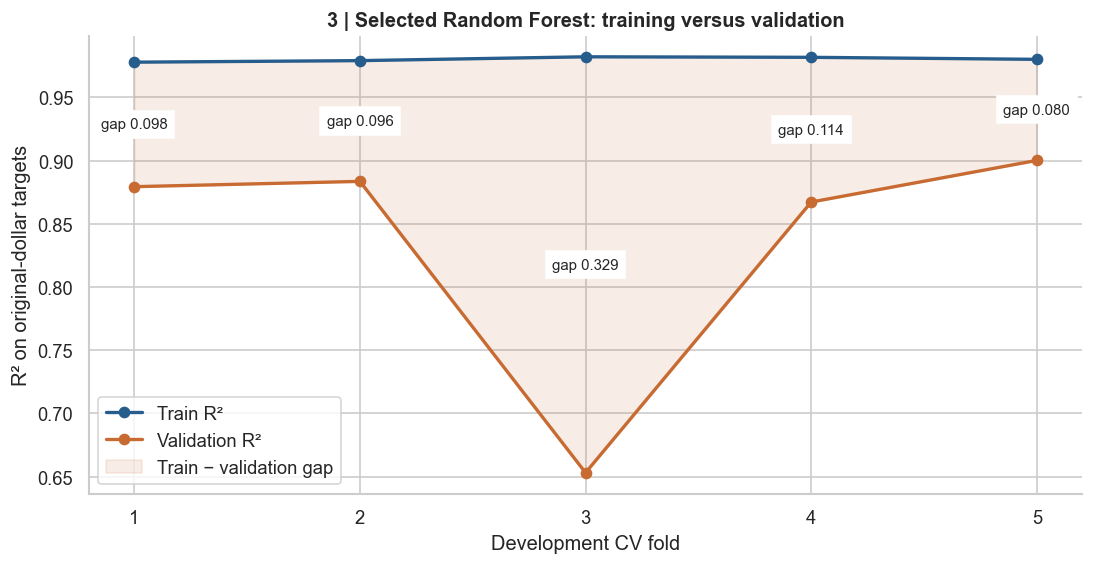

**Figure 3 interpretation.** Mean training R² is **0.98013**, mean validation R² is **0.83664**, and the gap is **0.14348**. Fold gaps range from 0.07994 to 0.32899. These paired values quantify the training–validation difference; they do not establish performance on a new independent dataset.

In [8]:
fig, ax = plt.subplots(figsize=(9.0, 4.6), layout='constrained')
fold_x = fold_metrics['fold'].to_numpy()
ax.plot(fold_x, fold_metrics['train_r2'], 'o-', color=BLUE, label='Train R²', lw=2)
ax.plot(fold_x, fold_metrics['validation_r2'], 'o-', color=ORANGE, label='Validation R²', lw=2)
ax.fill_between(fold_x, fold_metrics['validation_r2'], fold_metrics['train_r2'],
                color=ORANGE, alpha=.12, label='Train − validation gap')
for _, record in fold_metrics.iterrows():
    middle = (record['train_r2'] + record['validation_r2']) / 2
    ax.text(record['fold'], middle, f'gap {record["overfit_gap"]:.3f}',
            ha='center', va='center', fontsize=9, backgroundcolor='white')
ax.set(xticks=fold_x, xlabel='Development CV fold', ylabel='R² on original-dollar targets',
       title='3 | Selected Random Forest: training versus validation')
ax.legend(loc='lower left', frameon=True)
plt.show()
plt.close(fig)
display(Markdown(
    f'**Figure 3 interpretation.** Mean training R² is **{means["train_r2"]:.5f}**, '
    f'mean validation R² is **{means["validation_r2"]:.5f}**, and the gap is '
    f'**{means["train_r2"] - means["validation_r2"]:.5f}**. '
    f'Fold gaps range from {fold_metrics["overfit_gap"].min():.5f} to '
    f'{fold_metrics["overfit_gap"].max():.5f}. These paired values quantify the '
    'training–validation difference; they do not establish performance on a new independent dataset.'
))

## 12. Dollar-scale prediction diagnostics
Every point below is a validation prediction from a model that did not fit that row. However, selection of the shared hyperparameters used these same development folds. Residual is defined as actual price minus predicted price: positive values mean underprediction.

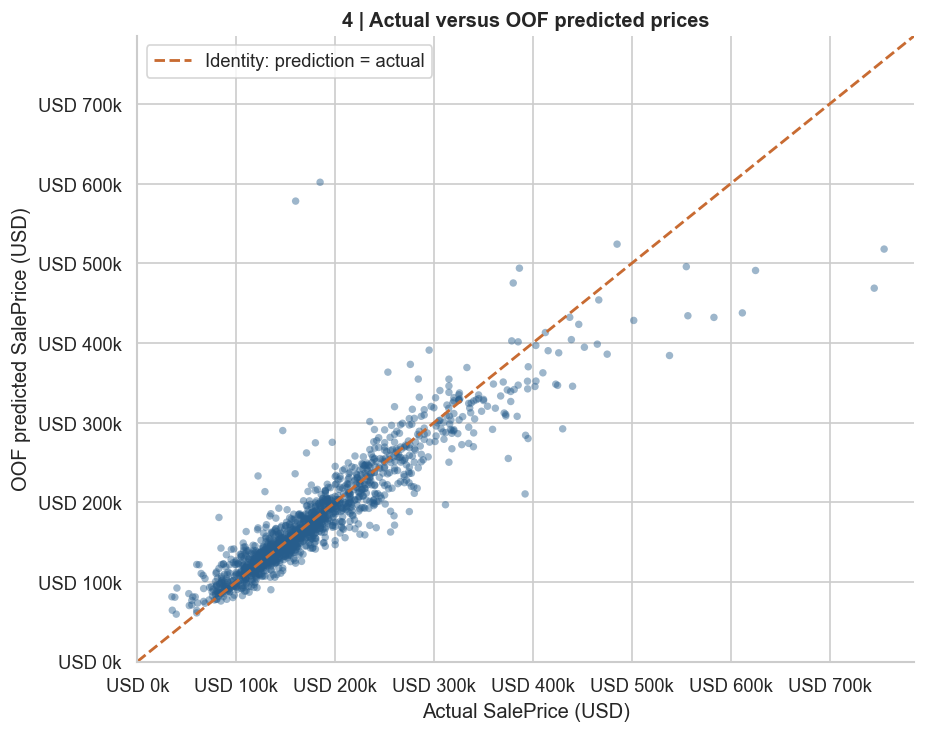

**Figure 4 interpretation.** All **1,460** houses have exactly one held-out prediction. Pooled OOF RMSE is **USD 31,592.17** and pooled OOF R² is **0.84175**. Points below the line are underpredictions. These are pooled development-CV diagnostics, not final full-data fitted predictions or the primary mean-fold comparison values.

In [9]:
fig, ax = plt.subplots(figsize=(7.6, 6.0), layout='constrained')
ax.scatter(y_dollars, oof_predictions, s=20, alpha=.45, color=BLUE, edgecolors='none')
upper = float(max(y_dollars.max(), oof_predictions.max()) * 1.04)
ax.plot([0, upper], [0, upper], '--', color=ORANGE, lw=1.7, label='Identity: prediction = actual')
ax.set(xlim=(0, upper), ylim=(0, upper), xlabel='Actual SalePrice (USD)',
       ylabel='OOF predicted SalePrice (USD)', title='4 | Actual versus OOF predicted prices')
ax.xaxis.set_major_formatter(dollar_axis)
ax.yaxis.set_major_formatter(dollar_axis)
ax.legend(loc='upper left')
plt.show()
plt.close(fig)
display(Markdown(
    f'**Figure 4 interpretation.** All **{len(oof_table):,}** houses have exactly one held-out '
    f'prediction. Pooled OOF RMSE is **USD {oof_metrics["oof_rmse_dollars"]:,.2f}** and '
    f'pooled OOF R² is **{oof_metrics["oof_r2"]:.5f}**. Points below the line are '
    'underpredictions. These are pooled development-CV diagnostics, not final full-data fitted predictions '
    'or the primary mean-fold comparison values.'
))

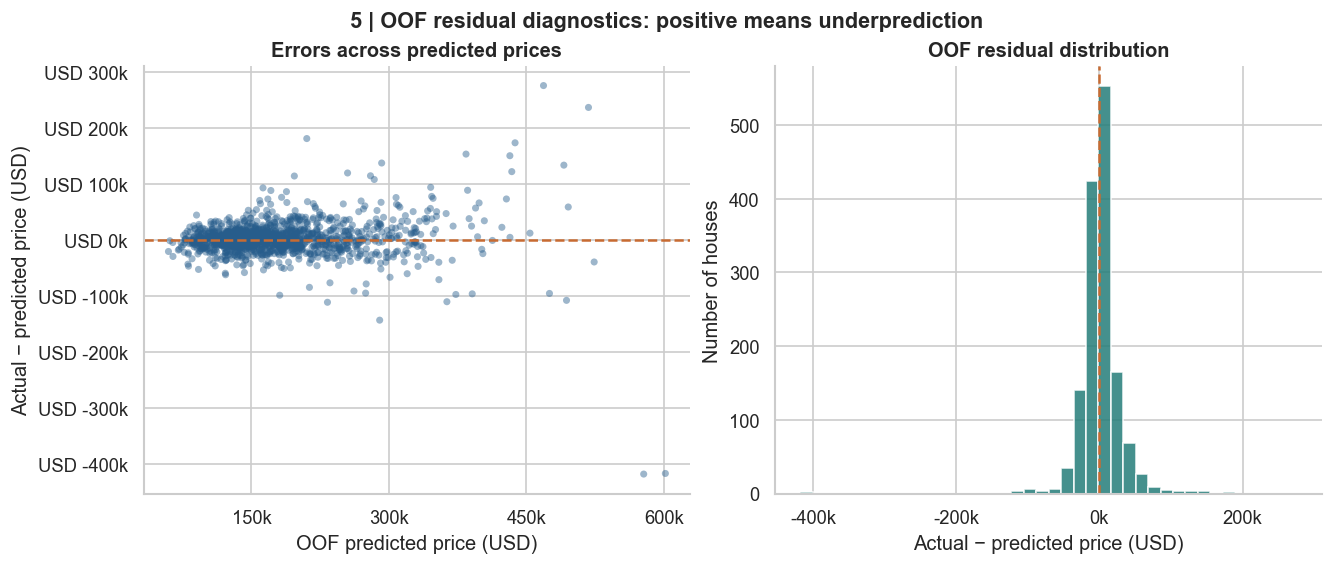

**Figure 5 interpretation.** Mean residual is **USD 2,334.15** and median residual is **USD 1,267.27**. **19** houses have absolute OOF errors above USD 100,000. RMSE gives these large errors more weight than MAE. The five largest absolute errors are retained below for transparent inspection; no rows are removed.

,Id,fold,actual_dollars,predicted_dollars,residual_dollars
0,1299,3,160000,577962.46,-417962.46
1,524,3,184750,601606.14,-416856.14
2,1183,2,745000,468647.45,276352.55
3,692,1,755000,517719.39,237280.61
4,689,4,392000,210352.04,181647.96


In [10]:
residuals = oof_table['residual_dollars'].to_numpy()
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.6), layout='constrained')
axes[0].scatter(oof_predictions, residuals, s=18, alpha=.45, color=BLUE, edgecolors='none')
axes[0].axhline(0, color=ORANGE, ls='--', lw=1.5)
axes[0].set(xlabel='OOF predicted price (USD)', ylabel='Actual − predicted price (USD)',
            title='Errors across predicted prices')
axes[0].xaxis.set_major_formatter(dollar_axis)
axes[0].yaxis.set_major_formatter(dollar_axis)
axes[1].hist(residuals, bins=40, color=TEAL, alpha=.85, edgecolor='white')
axes[1].axvline(0, color=ORANGE, ls='--', lw=1.5)
axes[1].set(xlabel='Actual − predicted price (USD)', ylabel='Number of houses',
            title='OOF residual distribution')
for axis in axes:
    axis.xaxis.set_major_locator(matplotlib.ticker.MaxNLocator(nbins=5))
    axis.xaxis.set_major_formatter(FuncFormatter(lambda value, pos: f'{value / 1000:,.0f}k'))
fig.suptitle('5 | OOF residual diagnostics: positive means underprediction', fontsize=13, weight='bold')
plt.show()
plt.close(fig)
display(Markdown(
    f'**Figure 5 interpretation.** Mean residual is **USD {residuals.mean():,.2f}** and '
    f'median residual is **USD {np.median(residuals):,.2f}**. '
    f'**{np.count_nonzero(np.abs(residuals) > 100_000)}** houses have absolute OOF errors above '
    'USD 100,000. RMSE gives these large errors more weight than MAE. The five largest '
    'absolute errors are retained below for transparent inspection; no rows are removed.'
))
worst_positions = np.argsort(np.abs(residuals))[-5:][::-1]
display(oof_table.iloc[worst_positions].round(2).reset_index(drop=True))

## 13. Final full-data Random Forest fit
Fit one fresh selected pipeline on all 1,460 labelled rows after the development evaluation is complete. This is the artifact for future prediction. Its fit supplies no new validation evidence, and no Kaggle test row is used to fit preprocessing or the forest.

In [11]:
final_pipeline = clone(selected_template)
assert not hasattr(final_pipeline.named_steps['prep'].named_steps['impute'], 'statistics_')
final_pipeline.fit(X, y_log)
final_prep = final_pipeline.named_steps['prep']
final_forest = final_pipeline.named_steps['reg']
assert final_prep.named_steps['impute'].fit_row_count_ == 1460
assert all(final_forest.get_params()[key] == value for key, value in best_params.items())
assert all(final_forest.get_params()[key] == value for key, value in FIXED_PARAMS.items())
small_matrix = final_prep.transform(X.iloc[:8])
assert isinstance(small_matrix, np.ndarray) and np.isfinite(small_matrix).all()
print(f'Final pipeline fitted on {len(X):,} labelled rows with selected parameters {best_params}.')
print('Predict returns log1p(SalePrice); apply np.expm1 once to obtain dollar predictions.')

Final pipeline fitted on 1,460 labelled rows with selected parameters {'max_depth': 20, 'n_estimators': 200}.
Predict returns log1p(SalePrice); apply np.expm1 once to obtain dollar predictions.


## 14. Feature importance / valuation analysis
Extract names from the same fitted preprocessor whose output trained the final forest. The top 15 are a subset of the complete importance distribution; their values are not renormalized.

Impurity importance describes contribution/use within this fitted Random Forest's log-target splits. It is **not causal**, does **not** show positive versus negative dollar effects, can favour some feature structures, and can be shared among correlated source and engineered features. This is interpretation of the full-data model, not held-out importance evidence.

Rank,Feature,Importance
1,numeric__OverallQual,0.45987
2,numeric__TotalIndoorAreaSF,0.29528
3,indicators__CentralAir,0.01833
4,numeric__GrLivArea,0.01468
5,numeric__GarageCars,0.01295
6,numeric__LotArea,0.01137
7,numeric__GarageArea,0.01115
8,numeric__YearRemodAdd,0.01021
9,numeric__BathroomEquivalent,0.00995
10,numeric__YearBuilt,0.00995


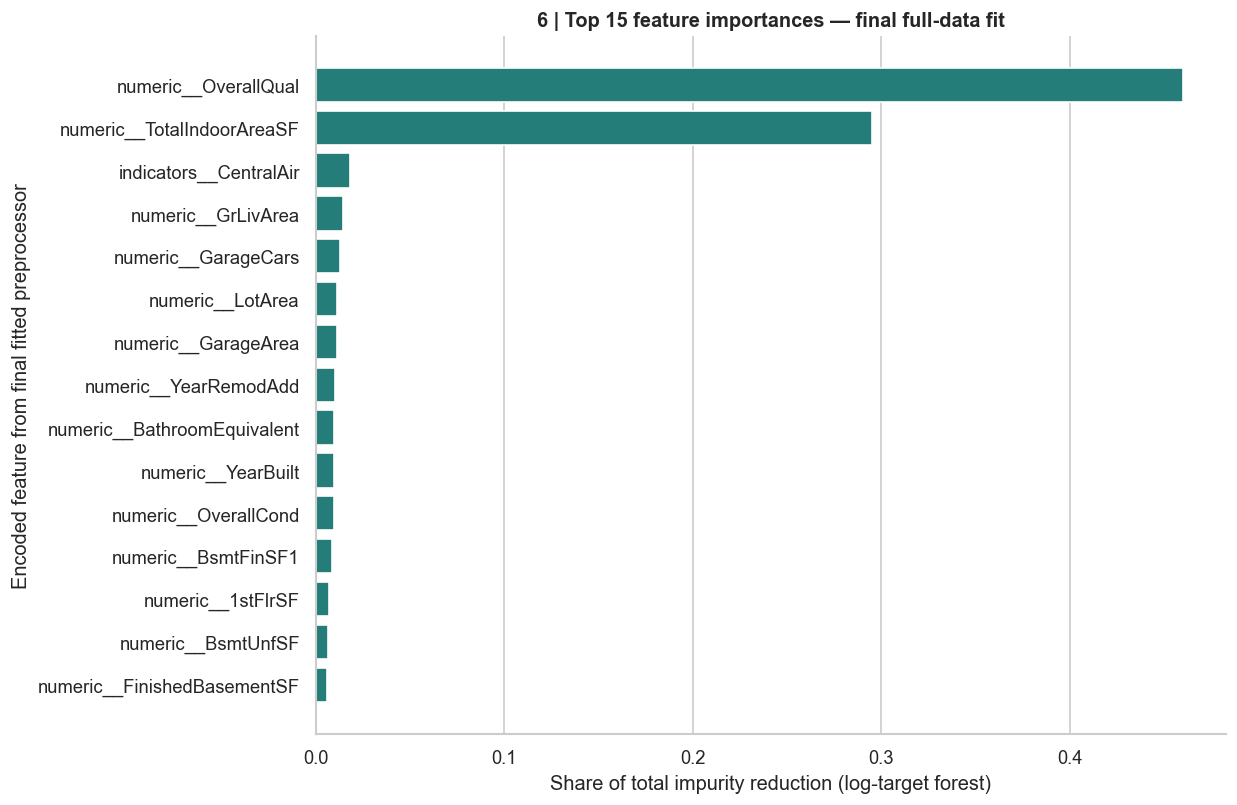

**Figure 6 interpretation.** The highest-ranked features are **numeric__OverallQual**, **numeric__TotalIndoorAreaSF**, **indicators__CentralAir**. The displayed 15 account for **89.1%** of total impurity importance across **300** transformed features. These values summarize how this fitted forest uses the representation; they do not quantify a causal or directional dollar effect.

In [12]:
names = get_feature_names(final_pipeline.named_steps['prep'])
importance = final_pipeline.named_steps['reg'].feature_importances_
assert len(names) == len(importance) == final_forest.n_features_in_
assert len(set(names)) == len(names)
assert np.isfinite(importance).all() and (importance >= 0).all()
assert np.isclose(importance.sum(), 1.0)
feature_count = int(len(names))
importance_table = pd.DataFrame({'Feature': names, 'Importance': importance})
importance_table = importance_table.sort_values('Importance', ascending=False, kind='stable').reset_index(drop=True)
importance_table.insert(0, 'Rank', np.arange(1, len(importance_table) + 1))
top15 = importance_table.head(15)
display(top15.style.format({'Importance': '{:.5f}'}).hide(axis='index'))

plot_top = top15.iloc[::-1]
fig, ax = plt.subplots(figsize=(10.2, 6.6), layout='constrained')
ax.barh(plot_top['Feature'], plot_top['Importance'], color=TEAL)
ax.set(xlabel='Share of total impurity reduction (log-target forest)',
       ylabel='Encoded feature from final fitted preprocessor',
       title='6 | Top 15 feature importances — final full-data fit')
ax.grid(axis='y', visible=False)
plt.show()
plt.close(fig)
leading_names = ', '.join('**' + name + '**' for name in top15['Feature'].head(3))
display(Markdown(
    f'**Figure 6 interpretation.** The highest-ranked features are {leading_names}. '
    f'The displayed 15 account for **{top15["Importance"].sum():.1%}** of total impurity importance '
    f'across **{feature_count}** transformed features. These values summarize how this fitted '
    'forest uses the representation; they do not quantify a causal or directional dollar effect.'
))

## 15. Save and reload model
Save the complete fitted preprocessing + RandomForestRegressor pipeline in the member notebook folder. Reload it and compare predictions on a small raw-predictor sample. The consumer must retain the importable src.member_03 package and a compatible environment.

Inference contract: **loaded_pipeline.predict(raw_X) returns log1p dollars; apply np.expm1 exactly once.**

In [13]:
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(final_pipeline, MODEL_PATH, compress=3)
loaded_pipeline = joblib.load(MODEL_PATH)
raw_X_sample = X.iloc[[0, 100, 500, 1000, 1459]].copy()
pred_log = loaded_pipeline.predict(raw_X_sample)
pred_dollars = np.expm1(pred_log)
reference_log = final_pipeline.predict(raw_X_sample)
reference_dollars = np.expm1(reference_log)
# Parallel tree summation can differ at floating-point roundoff level.
np.testing.assert_allclose(pred_log, reference_log, rtol=1e-12, atol=1e-12)
np.testing.assert_allclose(pred_dollars, reference_dollars, rtol=1e-12, atol=1e-8)
assert list(loaded_pipeline.named_steps) == ['prep', 'reg']
assert loaded_pipeline.named_steps['prep'].named_steps['impute'].fit_row_count_ == 1460
assert all(loaded_pipeline.named_steps['reg'].get_params()[k] == v for k, v in best_params.items())
model_size_bytes = MODEL_PATH.stat().st_size
display(pd.DataFrame({'Id': train_df.loc[raw_X_sample.index, 'Id'].to_numpy(),
                      'Prediction log1p dollars': pred_log, 'Prediction dollars': pred_dollars}))
print(f'Save/reload equality: PASS within numerical tolerance; max dollar difference '
      f'{np.max(np.abs(pred_dollars - reference_dollars)):.12f}.')
print(f'{MODEL_PATH.relative_to(ROOT).as_posix()} — {model_size_bytes:,} bytes '
      f'({model_size_bytes / 1024**2:.2f} MiB).')

,Id,Prediction log1p dollars,Prediction dollars
0,1,12.247399,208437.535236
1,101,12.227829,204397.898506
2,501,11.651411,114852.336793
3,1001,11.327620,83084.079320
4,1460,11.899732,147226.235465


Save/reload equality: PASS within numerical tolerance; max dollar difference 0.000000000815.
notebooks/Member_03/random_forest_model.joblib — 6,443,296 bytes (6.14 MiB).


## 16. Export metrics JSON
Export actual computed values with explicit scale, aggregation and development-CV metadata. Primary scores are fold means; pooled OOF values have separate keys. Fold validation IDs allow the master comparison to confirm identical memberships. Feature count refers to the final full-data fit and may differ from fold counts.

Serialization rejects NaN and Infinity. The exported file is read back and compared with the in-memory metrics, and primary values are checked against the fold records.

In [14]:
metrics = {
    'schema_version': 1, 'member': 3, 'name': 'Ahamed M.A.W',
    'student_id': 'IT24103352', 'group': '2026-AI-08K', 'model': 'RandomForestRegressor',
    'best_params': best_params, 'fixed_params': FIXED_PARAMS,
    'preprocessing': {'configuration': 'unscaled', 'log_numeric': False, 'sparse_output': False},
    'cv_strategy': 'KFold', 'cv_folds': 5, 'cv_shuffle': True, 'random_state': 42,
    'evaluation_protocol': '5-fold development cross-validation',
    'selection_metric': 'mean validation RMSE in dollars',
    'target_transformation': 'log1p', 'inverse_target_transformation': 'expm1',
    'metric_scale': 'original dollars', 'metric_aggregation': 'mean across 5 validation folds',
    'std_ddof': 0,
    'cv_rmse_dollars': float(means['validation_rmse_dollars']),
    'cv_rmse_std_dollars': float(stds['validation_rmse_dollars']),
    'cv_mae_dollars': float(means['validation_mae_dollars']),
    'cv_mae_std_dollars': float(stds['validation_mae_dollars']),
    'cv_r2': float(means['validation_r2']), 'cv_r2_std': float(stds['validation_r2']),
    'train_r2': float(means['train_r2']), 'validation_r2': float(means['validation_r2']),
    'overfit_gap': float(means['train_r2'] - means['validation_r2']),
    **oof_metrics,
    'fold_metrics': fold_records, 'fold_validation_ids': fold_validation_ids,
    'training_rows': int(len(X)), 'feature_count': feature_count,
    'feature_count_basis': 'final full-training fit on all 1460 labelled rows',
    'model_path': MODEL_PATH.relative_to(ROOT).as_posix(),
    'model_prediction_scale': 'log1p dollars; apply expm1 for dollar prediction',
    'package_versions': package_versions, 'provenance': provenance,
}


def check_json_values(value):
    if isinstance(value, dict):
        assert all(isinstance(key, str) for key in value)
        for item in value.values():
            check_json_values(item)
    elif isinstance(value, list):
        for item in value:
            check_json_values(item)
    elif type(value) is float:
        assert np.isfinite(value), 'Nonfinite JSON value'
    else:
        assert type(value) in (str, int, bool, type(None)), f'Unsupported JSON type: {type(value)}'


check_json_values(metrics)
METRICS_PATH.parent.mkdir(parents=True, exist_ok=True)
METRICS_PATH.write_text(json.dumps(metrics, indent=2, allow_nan=False) + chr(10), encoding='utf-8')
exported_metrics = json.loads(METRICS_PATH.read_text(encoding='utf-8'))
assert exported_metrics == metrics
for primary, fold_key in [('cv_rmse_dollars', 'validation_rmse_dollars'),
                           ('cv_mae_dollars', 'validation_mae_dollars'),
                           ('cv_r2', 'validation_r2'), ('train_r2', 'train_r2')]:
    assert exported_metrics[primary] == float(fold_metrics[fold_key].mean())
assert exported_metrics['cv_r2'] == exported_metrics['validation_r2']
assert exported_metrics['overfit_gap'] == exported_metrics['train_r2'] - exported_metrics['validation_r2']
assert sha256(RAW_TRAIN_PATH) == provenance['raw_train_sha256']
assert sha256(PREPROCESSING_PATH) == provenance['preprocessing_sha256']
print('JSON finite/native values, read-back equality and fold-mean consistency: PASS.')
print(METRICS_PATH.relative_to(ROOT).as_posix())
display(pd.DataFrame({
    'Metric': ['CV RMSE (USD)', 'CV MAE (USD)', 'CV R²', 'Train R²', 'Validation R²', 'Overfit gap'],
    'Primary mean-fold value': [metrics[k] for k in ['cv_rmse_dollars', 'cv_mae_dollars',
        'cv_r2', 'train_r2', 'validation_r2', 'overfit_gap']],
}))

JSON finite/native values, read-back equality and fold-mean consistency: PASS.
reports/model_results/member3_rf_metrics.json


,Metric,Primary mean-fold value
0,CV RMSE (USD),30814.763412
1,CV MAE (USD),17506.273138
2,CV R²,0.836643
3,Train R²,0.980125
4,Validation R²,0.836643
5,Overfit gap,0.143483


## 17. Member 4 / master comparison handover
| Artifact | Repository-relative location |
|---|---|
| Executed experiment | notebooks/Member_03/Member3_Random_Forest.ipynb |
| Comparison metrics | reports/model_results/member3_rf_metrics.json |
| Complete fitted model | notebooks/Member_03/random_forest_model.joblib |

Use the JSON's cv_rmse_dollars, cv_mae_dollars, cv_r2, train_r2, validation_r2 and overfit_gap in the master table. Confirm the same raw-data fingerprint, validation IDs, dollar scale, fold-mean aggregation and development-CV protocol across members. Supplementary oof_* metrics are pooled and must not be substituted silently.

The explicit allocation is Member 1 XGBoost/baseline, Member 2 Ridge, Member 3 Random Forest, Member 4 LightGBM/comparison. Contradictory example owner labels and metric filenames in the guide are not followed. This notebook makes no group-wide winner claim.

Load the joblib artifact with the repository's src package available. Supply a named raw-predictor DataFrame using the shared semantic input contract; the full property schema is required. Convert predictions with expm1. The saved pipeline contains learned preprocessing and the forest, but deliberately leaves the target inversion explicit.

## 18. Limitations and Member 3 summary
- **Development selection optimism:** the same five folds select and evaluate the configuration. Fresh fold fits protect preprocessing boundaries but do not make model selection independent. No nested CV or independent holdout is claimed.
- **Fixed scope:** only the assigned six candidates are compared. The selected configuration is best within this search, not universally optimal.
- **Dollar errors after log fitting:** training optimizes squared errors in log space; inverse-transformed averages are not guaranteed to estimate the arithmetic conditional mean price. No unrequested bias correction is applied.
- **Dataset scope:** random Ames folds do not establish performance in a different market or future period. Earlier EDA examined the labelled dataset, and Kaggle test labels are unavailable.
- **Representation assumptions:** existing structural-absence rules, ordinal ranks, imputation flags, retained unusual properties and related source/aggregate features are inherited unchanged. Warnings are not suppressed.
- **Valuation interpretation:** impurity importance is model-specific and noncausal, lacks effect direction and can distribute importance across related variables.
- **Reproducibility:** recorded versions, hashes and seeds support reruns; parallel floating-point reductions can differ at roundoff level. Standard deviations describe these five folds, not population uncertainty.

**AI-use transparency:** AI assistance supported notebook implementation and verification. The student should review the reasoning, explain the outputs and disclose assistance according to the assignment requirements.

In [15]:
display(Markdown(
    f'**Executed Member 3 result.** The selected forest uses **{best_params["n_estimators"]} trees** '
    f'and **max_depth={best_params["max_depth"]}**. Primary mean-fold dollar RMSE is '
    f'**USD {metrics["cv_rmse_dollars"]:,.2f}**, MAE is **USD {metrics["cv_mae_dollars"]:,.2f}**, '
    f'and R² is **{metrics["cv_r2"]:.5f}**. The final artifact contains preprocessing plus '
    f'the selected forest fitted on **{metrics["training_rows"]:,} rows** and '
    f'**{feature_count} transformed features**. Six figures, fold evidence, '
    'OOF diagnostics and the machine-readable metrics support the handover.'
))
assert len(fold_records) == 5 and np.all(oof_coverage == 1)
assert model_size_bytes > 0 and exported_metrics == metrics
print('Execution verification complete: 30 search fits + 5 evaluation fits + 1 final fit.')

**Executed Member 3 result.** The selected forest uses **200 trees** and **max_depth=20**. Primary mean-fold dollar RMSE is **USD 30,814.76**, MAE is **USD 17,506.27**, and R² is **0.83664**. The final artifact contains preprocessing plus the selected forest fitted on **1,460 rows** and **300 transformed features**. Six figures, fold evidence, OOF diagnostics and the machine-readable metrics support the handover.

Execution verification complete: 30 search fits + 5 evaluation fits + 1 final fit.
